# Assignment 3: Time Series Prediction of Sepsis

Author: 
Maximilian Rauer

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import seaborn as sns
from sklearn.model_selection import train_test_split
from numpy import ma
import math 

## Load Data

In [2]:

def load_sepsis_data(file_names, file_path="raw_data/"):
    """
    This function loads the sepsis data from the specified files and returns a list of pandas DataFrames.
    
    :param file_names: The filenames of the data files to load
    :param file_path: The path to the directory containing the data files
    """

    dfs = []
    for file_name in file_names:
        df = pd.read_csv(os.path.join(file_path, file_name), delimiter="\t")
        dfs.append(df)
    return dfs

In [3]:
data_files = ["sepsisexp_timeseries_partition-A.tsv", 
              "sepsisexp_timeseries_partition-B.tsv", 
              "sepsisexp_timeseries_partition-C.tsv", 
              "sepsisexp_timeseries_partition-D.tsv"]

dfs = load_sepsis_data(data_files)

## Task 1: Implement your own neural network to predict the onset of Sepsis 2, 4 and 6 hours in advance...

### Step 1: Analyze the data

In [4]:
def count_sepsis_patients(dfs):
    """
    This function counts the number of unique patients in the provided list of DataFrames.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    :return: The total number of unique patients across all DataFrames
    """

    sepsis = set()
    no_sepsis = set()

    for df in dfs: 
        for id in df["id"].unique():
            if df[df["id"] == id]["sepsis"].iloc[0] == 1:
                sepsis.add(id)
            else:
                no_sepsis.add(id)

    return len(sepsis), len(no_sepsis)

In [5]:
num_sepsis, num_no_sepsis = count_sepsis_patients(dfs)
print(f"Number of sepsis patients: {num_sepsis}")
print(f"Number of non-sepsis patients: {num_no_sepsis}")

Number of sepsis patients: 296
Number of non-sepsis patients: 979


In [6]:
def analyze_sequence_lengths(dfs):
    """
    This function analyzes the sequence lengths of the patient data in the provided list of DataFrames.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    :return: A list of sequence lengths for each patient across all DataFrames
    """

    sequence_lengths = []

    for df in dfs:
        for id in df["id"].unique():
            length = len(df[df["id"] == id]["timestep"])
            sequence_lengths.append({"id": id, "timesteps": length})

    return sequence_lengths

In [7]:
sequence_lengths = analyze_sequence_lengths(dfs)
print(f"Sequence lengths: {sequence_lengths}")

# calulcate shortest sequence length 
min_length = min([seq["timesteps"] for seq in sequence_lengths])
print(f"Shortest sequence length: {min_length}")

# calculate number of occurrences for sequence length of below 4 hours 
num_below_4 = sum([1 for seq in sequence_lengths if seq["timesteps"] < 8]) # 8 timesteps correspond to 4 hours (since each timestep is 30 minutes)
print(f"Number of occurrences of sequence length below 4 hours: {num_below_4}")

Sequence lengths: [{'id': np.int64(12292), 'timesteps': 134}, {'id': np.int64(13997), 'timesteps': 840}, {'id': np.int64(12305), 'timesteps': 345}, {'id': np.int64(12307), 'timesteps': 255}, {'id': np.int64(12320), 'timesteps': 89}, {'id': np.int64(12328), 'timesteps': 217}, {'id': np.int64(12330), 'timesteps': 92}, {'id': np.int64(12331), 'timesteps': 95}, {'id': np.int64(12357), 'timesteps': 39}, {'id': np.int64(12359), 'timesteps': 804}, {'id': np.int64(12362), 'timesteps': 319}, {'id': np.int64(12366), 'timesteps': 42}, {'id': np.int64(12367), 'timesteps': 428}, {'id': np.int64(12372), 'timesteps': 38}, {'id': np.int64(12390), 'timesteps': 48}, {'id': np.int64(12393), 'timesteps': 949}, {'id': np.int64(12400), 'timesteps': 66}, {'id': np.int64(12401), 'timesteps': 132}, {'id': np.int64(12404), 'timesteps': 229}, {'id': np.int64(12405), 'timesteps': 53}, {'id': np.int64(12411), 'timesteps': 220}, {'id': np.int64(12413), 'timesteps': 94}, {'id': np.int64(12414), 'timesteps': 48}, {'i

I checked for the sequence length in order to see if there are any extremely long or extremely short hospital stays in the dataset. In order to predict stays of four hours or more (as stated in the task), it is recommended to have data that spans at least four hours. The analysis shows that there are no occurrences of patients that stayed less than 4 hours. 

In [8]:
# check for missing values 
def check_missing_values(dfs):
    """
    This function checks for missing values in the provided list of DataFrames and prints the count of missing values for each column.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    """

    for df in dfs:
        missing_values = df.isnull().sum()
        print(f"Missing values in DataFrame:\n{missing_values}\n")
        total_missing = missing_values.sum()
        print(f"Total missing values: {total_missing}\n")

In [9]:
check_missing_values(dfs)

Missing values in DataFrame:
id                                0
sepsis                            0
severity                          0
timestep                          0
respiratory_minute_volume         0
heart_rate                        0
leukocytes                        0
temperature                       0
partial_co2                       0
respiratory_rate                  0
arterial_ph                       0
bilirubin                         0
blood_urea_nitrogen               0
creatinine                        0
diastolic_bp                      0
fraction_of_inspired_o2           0
mean_bp                           0
partial_pressure_art._o2          0
systolic_bp                       0
thrombocytes                      0
horowitz_index                    0
bun/creatinine_ratio              0
delta-temperature                 0
lactate                           0
bicarbonate                       0
c-reactive_protein                0
hemoglobin                        0

The check for missing values confirms that we have no missing values in the datasets and can continue with further data evaluation and analysis. 

In [10]:
# calculate correlations 
def calculate_correlations(dfs):
    """
    This function calculates the correlation between each feature and the target variable 'sepsis' in the provided list of DataFrames.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    :return: A list of correlation values for each feature across all DataFrames
    """

    correlations = []

    for df in dfs:
        corr = df.drop(columns=["id"]).corrwith(df["sepsis"]).sort_values(ascending=False)

        corr = corr.drop("sepsis")  # drop the correlation of 'sepsis' with itself
        correlations.append(corr)

        print(f"top 5 positive correlations:\n{corr.head(5)}\n")
        print(f"top 5 negative correlations:\n{corr.tail(5)}\n")

    return correlations

def plot_correlations(correlations): 
    """
    This function plots the correlation values for each feature across all DataFrames.
    
    :param correlations: A list of correlation values for each feature across all DataFrames
    """

    for i, corr in enumerate(correlations): 
        plt.figure(figsize=(10, 10))
        sns.barplot(x=corr.values, y=corr.index, palette="coolwarm", hue=corr.index, legend=False)
        plt.title(f"Correlation of features with sepsis in DataFrame {i+1}")
        plt.ylabel("Features")
        plt.xlabel("Correlation with sepsis")
        plt.show()

top 5 positive correlations:
severity               0.546265
blood_urea_nitrogen    0.339235
timestep               0.330778
c-reactive_protein     0.312802
heart_time_volume      0.306260
dtype: float64

top 5 negative correlations:
urine_output   -0.148915
mean_bp        -0.167382
systolic_bp    -0.181995
svri           -0.297722
hemoglobin     -0.334311
dtype: float64

top 5 positive correlations:
severity              0.507692
timestep              0.374929
heart_time_volume     0.268076
c-reactive_protein    0.250956
heart_rate            0.221490
dtype: float64

top 5 negative correlations:
diastolic_bp   -0.138816
mean_bp        -0.166712
systolic_bp    -0.196368
svri           -0.289752
hemoglobin     -0.318962
dtype: float64

top 5 positive correlations:
severity                0.520748
timestep                0.387060
c-reactive_protein      0.241477
bun/creatinine_ratio    0.212687
blood_urea_nitrogen     0.207824
dtype: float64

top 5 negative correlations:
diastolic_bp   -

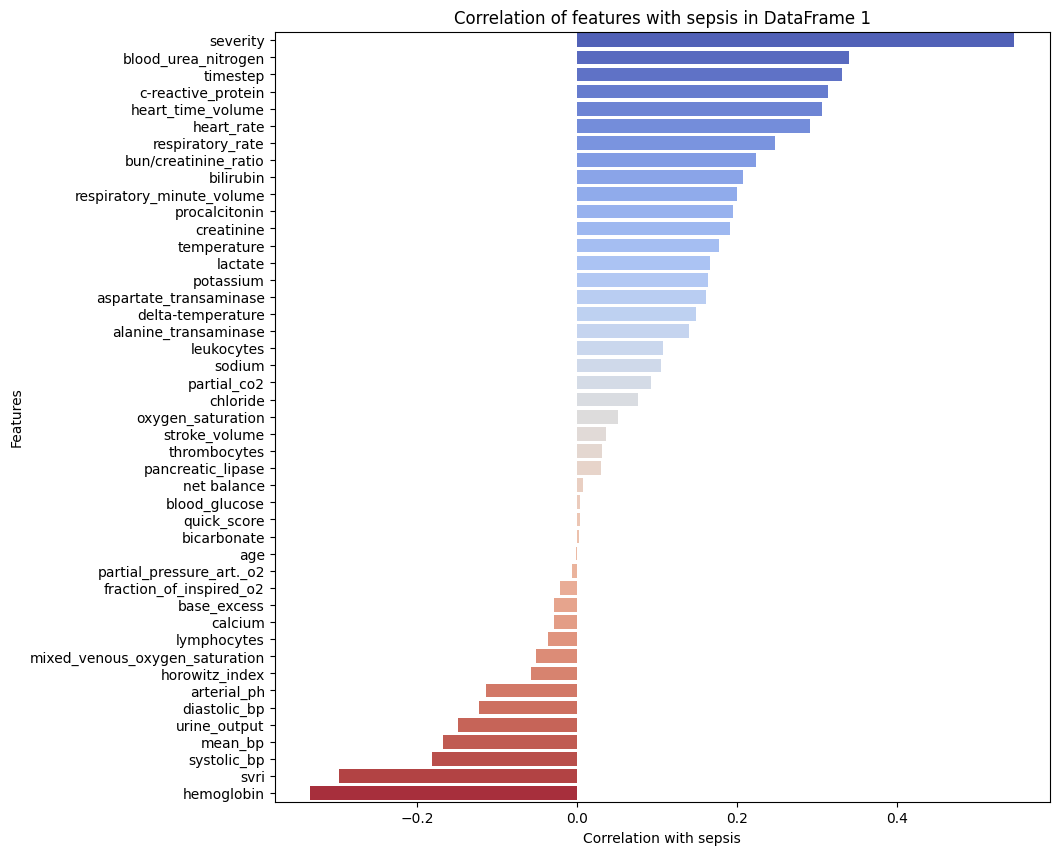

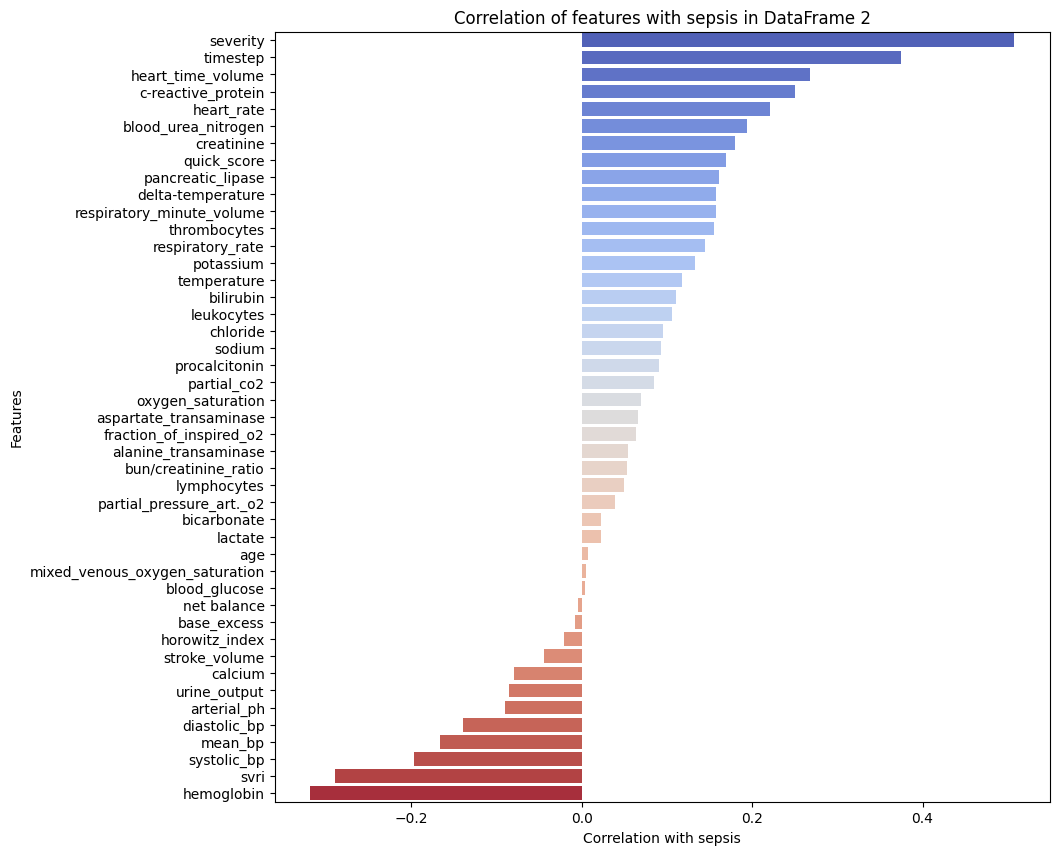

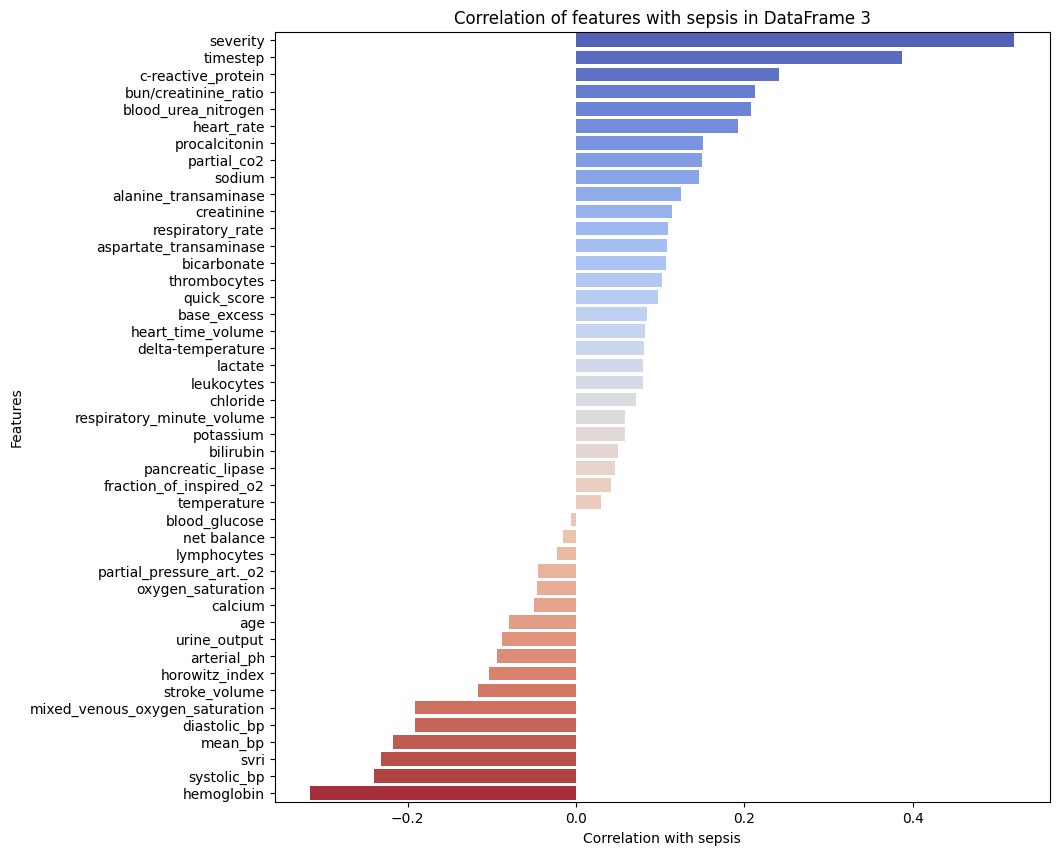

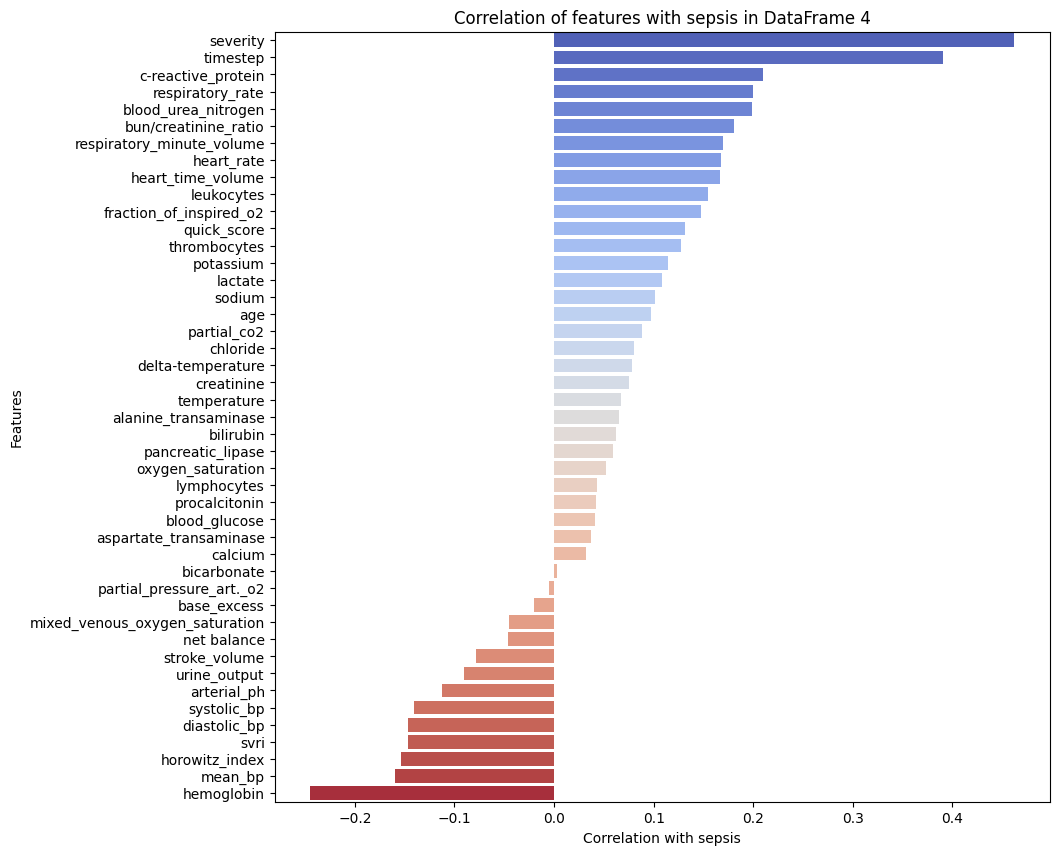

In [11]:
correlations = calculate_correlations(dfs)
print(f"Correlations:\n{correlations}")

plot_correlations(correlations)

In [12]:
## calculate the mean and the standard deviation of the timesteps for each of the dataframes 
def calculate_timestep_stats(dfs):
    """
    This function calculates the mean and standard deviation of the timesteps for each DataFrame in the provided list.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    :return: A list of dictionaries containing the mean and standard deviation of timesteps for each DataFrame
    """

    stats = []

    for df in dfs:
        mean_timesteps = df.groupby("id")["timestep"].max().mean()
        std_timesteps = df.groupby("id")["timestep"].max().std()
        stats.append({"mean": mean_timesteps, "std": std_timesteps})
        print(f"DataFrame stats - Mean timesteps: {mean_timesteps}, Std timesteps: {std_timesteps}")

    return stats

In [13]:
stats = calculate_timestep_stats(dfs)

DataFrame stats - Mean timesteps: 245.11755485893417, Std timesteps: 379.8733024539536
DataFrame stats - Mean timesteps: 237.98746081504703, Std timesteps: 335.5557084748718
DataFrame stats - Mean timesteps: 244.3573667711599, Std timesteps: 357.360428224739
DataFrame stats - Mean timesteps: 215.67924528301887, Std timesteps: 302.9452417596147


In [14]:
# perform shapiro wilk test for normality on the features
from scipy.stats import shapiro

def perform_shapiro_wilk_test(dfs):
    """
    This function performs the Shapiro-Wilk test for normality on the features in the provided list of DataFrames and prints the results.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    """

    for df in dfs:
        normally_distributed_features = []
        print(f"Shapiro-Wilk test results for DataFrame:")
        for column in df.columns:
            if column not in ["id", "timestep", "sepsis"]:
                stat, p_value = shapiro(df[column].dropna())
                print(f"Feature: {column}, Statistic: {stat}, P-value: {p_value}")
                if p_value < 0.05:
                    print(f"Feature {column} is not normally distributed (reject null hypothesis)")
                else:
                    print(f"Feature {column} is normally distributed (fail to reject null hypothesis)")
                    normally_distributed_features.append(column)
        print(f"Normally distributed features: {normally_distributed_features}\n")
        print("\n")

In [15]:
perform_shapiro_wilk_test(dfs)

Shapiro-Wilk test results for DataFrame:
Feature: severity, Statistic: 0.768027839045298, P-value: 2.563483617718387e-147
Feature severity is not normally distributed (reject null hypothesis)
Feature: respiratory_minute_volume, Statistic: 0.9472101291678638, P-value: 2.963818193770854e-104
Feature respiratory_minute_volume is not normally distributed (reject null hypothesis)
Feature: heart_rate, Statistic: 0.9795180656994097, P-value: 1.155133151205991e-80
Feature heart_rate is not normally distributed (reject null hypothesis)
Feature: leukocytes, Statistic: 0.9029995591997126, P-value: 4.848390445288834e-121
Feature leukocytes is not normally distributed (reject null hypothesis)
Feature: temperature, Statistic: 0.9707619864263766, P-value: 3.593672141643134e-89
Feature temperature is not normally distributed (reject null hypothesis)
Feature: partial_co2, Statistic: 0.9568526561227296, P-value: 5.700642136967658e-99
Feature partial_co2 is not normally distributed (reject null hypothesi

/Users/maximilianrauer/Anaconda/anaconda3/envs/cm2011-lab1/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 156704.
  res = hypotest_fun_out(*samples, **kwds)
/Users/maximilianrauer/Anaconda/anaconda3/envs/cm2011-lab1/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 152155.
  res = hypotest_fun_out(*samples, **kwds)


Feature: mean_bp, Statistic: 0.9588656630489727, P-value: 3.4079795931380456e-97
Feature mean_bp is not normally distributed (reject null hypothesis)
Feature: partial_pressure_art._o2, Statistic: 0.8475230486077906, P-value: 1.0819842024950356e-133
Feature partial_pressure_art._o2 is not normally distributed (reject null hypothesis)
Feature: systolic_bp, Statistic: 0.9565144355714117, P-value: 1.2701716208969595e-98
Feature systolic_bp is not normally distributed (reject null hypothesis)
Feature: thrombocytes, Statistic: 0.9382859955183902, P-value: 7.281402043774574e-108
Feature thrombocytes is not normally distributed (reject null hypothesis)
Feature: horowitz_index, Statistic: 0.8932955037846904, P-value: 3.654997706990767e-123
Feature horowitz_index is not normally distributed (reject null hypothesis)
Feature: bun/creatinine_ratio, Statistic: 0.8936059438337512, P-value: 4.436333285528699e-123
Feature bun/creatinine_ratio is not normally distributed (reject null hypothesis)
Feature

/Users/maximilianrauer/Anaconda/anaconda3/envs/cm2011-lab1/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 156219.
  res = hypotest_fun_out(*samples, **kwds)
/Users/maximilianrauer/Anaconda/anaconda3/envs/cm2011-lab1/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 137490.
  res = hypotest_fun_out(*samples, **kwds)


Feature: sodium, Statistic: 0.9312536726964598, P-value: 2.5295442991186887e-111
Feature sodium is not normally distributed (reject null hypothesis)
Feature: pancreatic_lipase, Statistic: 0.489202962299915, P-value: 2.7727626031441795e-173
Feature pancreatic_lipase is not normally distributed (reject null hypothesis)
Feature: procalcitonin, Statistic: 0.2427045867264861, P-value: 4.483550153983564e-187
Feature procalcitonin is not normally distributed (reject null hypothesis)
Feature: quick_score, Statistic: 0.48824885823111186, P-value: 2.3922928502877993e-173
Feature quick_score is not normally distributed (reject null hypothesis)
Feature: oxygen_saturation, Statistic: 0.7456953288753276, P-value: 3.6262562420412814e-150
Feature oxygen_saturation is not normally distributed (reject null hypothesis)
Feature: blood_glucose, Statistic: 0.8687547417453647, P-value: 8.651168864809668e-130
Feature blood_glucose is not normally distributed (reject null hypothesis)
Feature: base_excess, Stat

In [16]:
# use the IQR method to determine outliers for each feature in the dataframes
def identify_outliers_iqr(dfs):
    """
    This function identifies outliers in the features of the provided list of DataFrames using the Interquartile Range (IQR) method and prints the results.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    """
    
    all_outliers = []

    for i, df in enumerate(dfs):
        outliers_per_df = []
        print(f"Outlier detection using IQR method for DataFrame: {i + 1}")
        for column in df.columns:
            if column not in ["id", "timestep", "sepsis"]:
                Q1 = df[column].quantile(0.25)
                Q3 = df[column].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
                outliers_per_df.append({"feature": column, "num_outliers": len(outliers)})
                print(f"Feature: {column}, Number of outliers: {len(outliers)}")
        print("\n")
        all_outliers.append(outliers_per_df)
    return all_outliers


In [17]:
outliers = identify_outliers_iqr(dfs)

Outlier detection using IQR method for DataFrame: 1
Feature: severity, Number of outliers: 0
Feature: respiratory_minute_volume, Number of outliers: 15381
Feature: heart_rate, Number of outliers: 1169
Feature: leukocytes, Number of outliers: 5828
Feature: temperature, Number of outliers: 4274
Feature: partial_co2, Number of outliers: 3426
Feature: respiratory_rate, Number of outliers: 2180
Feature: arterial_ph, Number of outliers: 4238
Feature: bilirubin, Number of outliers: 18155
Feature: blood_urea_nitrogen, Number of outliers: 12863
Feature: creatinine, Number of outliers: 14147
Feature: diastolic_bp, Number of outliers: 2663
Feature: fraction_of_inspired_o2, Number of outliers: 69182
Feature: mean_bp, Number of outliers: 2455
Feature: partial_pressure_art._o2, Number of outliers: 3494
Feature: systolic_bp, Number of outliers: 2473
Feature: thrombocytes, Number of outliers: 5597
Feature: horowitz_index, Number of outliers: 4953
Feature: bun/creatinine_ratio, Number of outliers: 6790

There are a lot of outliers for most of the features. In order to account for these without removing them, I am using capping by applying the Winsorizer. 

In [18]:
from feature_engine.outliers import Winsorizer

def apply_capping(dfs): 
    """
    This function applies capping to the features in the provided list of DataFrames using the Winsorizer from the feature_engine library.
    
    :param dfs: A list of pandas DataFrames containing the sepsis data
    :return: A list of DataFrames with capped features
    """

    capped_dfs = []
    for df in dfs:
        capped_df = df.copy()
        for column in df.columns:
            if column not in ["id", "timestep", "sepsis"]:
                winsorizer = Winsorizer(capping_method="iqr", tail="both", fold=1.5)
                capped_df[column] = winsorizer.fit_transform(capped_df[[column]])
        capped_dfs.append(capped_df)
    
    return capped_dfs

In [19]:
capped_dfs = apply_capping(dfs)
new_outliers = identify_outliers_iqr(capped_dfs)

Outlier detection using IQR method for DataFrame: 1
Feature: severity, Number of outliers: 0
Feature: respiratory_minute_volume, Number of outliers: 0
Feature: heart_rate, Number of outliers: 0
Feature: leukocytes, Number of outliers: 0
Feature: temperature, Number of outliers: 0
Feature: partial_co2, Number of outliers: 0
Feature: respiratory_rate, Number of outliers: 0
Feature: arterial_ph, Number of outliers: 0
Feature: bilirubin, Number of outliers: 0
Feature: blood_urea_nitrogen, Number of outliers: 0
Feature: creatinine, Number of outliers: 0
Feature: diastolic_bp, Number of outliers: 0
Feature: fraction_of_inspired_o2, Number of outliers: 0
Feature: mean_bp, Number of outliers: 0
Feature: partial_pressure_art._o2, Number of outliers: 0
Feature: systolic_bp, Number of outliers: 0
Feature: thrombocytes, Number of outliers: 0
Feature: horowitz_index, Number of outliers: 0
Feature: bun/creatinine_ratio, Number of outliers: 0
Feature: delta-temperature, Number of outliers: 0
Feature:

I did the tests for normality to check which method to use for the data filtering of the training, test and validation data. The filtering of the data should help the model to better understand the data. The results show that the data is not normally distributed which means that I cannot use the mean and standard deviation to filter the data but instead have to use other methods such as the median and iqr (interquartile range proximity rule). But before applying robus scaling to filter the data, I'm using capping in order to adapt outliers to match the rest of the data without removing them. These methods are based on the information from the following website: https://www.blog.trainindata.com/detect-outliers-in-python/ 

We already know the distribution of sepsis vs. non-sepsis patients in each of the four datasets through the paper from Shamoni et al. which is distributed as follows: 245 non-sepsis patients and 74 sepsis patients are in each of the first three datasets (A-C) and 244 non-sepsis as well as 74 sepsis patients in the last dataset (D), adding up to a total of 979 non-sepsis and 296 sepsis patients across all datasets. In addition to that, the paper reveals that the meadian time of sepsis patients at the hospital is significantly higher than the time of non-sepsis patients. This trivially suggests that sepsis patients have generally longer hospital stays than non-sepsis patients. This significant correlation is also displayed in the correlation bar charts above. For the model training, we will consider excluding the timestep variable as this could cause unwanted conclusions of the model. The model could think that longer stays are a direct indicator for sepsis, removing patients with short stays from the list of potential sepsis patients which could be dangerous for cases where patients actually do have sepsis but detection through other parameters may be not immediately detactable. 

### Step 2: Data Processing and Creation of Folds 

In the following lines of code, I am viewing the four data sets as splits and create four different folds that represent the training, validation and test data. I create the folds as follows: for each fold, two datasets represent the training data, one the validation and one the test data. The selected dataframes are different for each folds, meaning that in the first fold datasets A and B are training data with C being used for validation and D for testing. In the next fold, the training data consists of data from datasets B and C, the validation data from data of D and the test data of data from A. The same logic is applied for the remaining four folds. 

All folds are saved in a dictionary with each fold containing data from input and target arrays for all three splits as well as their respective masked versions. 

In [20]:
# preparation of the data for model creation 
def prepare_data_for_model(df, sequence_length, n_features, hours_shift):
    """
    This method prepares the data into an input and a target array
    
    :param df: the dataframe to be used by the function 
    :param sequence_length: the target sequence length 
    :param n_features: the number of features to be considered for the target array 
    :param hours_shift: the amount of hours to be used for the prediction
    """

    grouped = df.groupby("id")
    n_samples = len(grouped)
    
    # creating placeholder arrays for the data 
    X = np.full((n_samples, sequence_length, n_features), -999.0)
    y = np.full((n_samples, sequence_length, 1), -1.0)

    # shift the steps to correctly index the data in the target array (i.e. 2 hours are step 4, etc.)
    shift_steps = int(hours_shift*2)

    # filling the arrays
    feature_cols = [c for c in df.columns if c not in ["id", "timestep", "sepsis"]]

    for i, (_, patient_data) in enumerate(grouped):
        # extract features and labels
        features = patient_data[feature_cols].values
        labels = patient_data["sepsis"].values
        
        # handle the length of the sequences 
        steps_to_take = min(len(features), sequence_length)

        # Fill X with all the features
        X[i, :steps_to_take, :] = features[:steps_to_take]

        # shift the y in order to be able to predict the future values
        if len(labels) > shift_steps: 
            future_labels = labels[shift_steps:]
            fill_len = min(steps_to_take, len(future_labels))

            # putting the data into the one-column array at index 0
            y[i, :fill_len, 0] = future_labels[:fill_len]

    # creating boolean masks that will be 1.0 for real data and 0.0 for padded data
    X_mask = (X != -999.0).astype(float)
    y_mask = (y != -1.0).astype(float)

    return X, y, X_mask, y_mask


def apply_robust_scaling(df_train_list, df_val, df_test, feature_cols): 
    """ 
    This method applies robust scaling to the input arrays of the train, validation and test sets. 
    The median and the interquartile range are calculated on the combined training data and then applied to all datasets.

    :param df_train_list: a list of the training dataframes
    :param df_val: the validation dataframe
    :param df_test: the test dataframe
    :param feature_cols: the columns that should be scaled
    """

    df_train_combined = pd.concat(df_train_list)

    median = df_train_combined[feature_cols].median()
    q25 = df_train_combined[feature_cols].quantile(0.25)
    q75 = df_train_combined[feature_cols].quantile(0.75)
    iqr = (q75 - q25).replace(0, 1)  # Avoid division by zero

    for df in df_train_list: 
        df[feature_cols] = (df[feature_cols] - median) / iqr

    df_val[feature_cols] = (df_val[feature_cols] - median) / iqr
    df_test[feature_cols] = (df_test[feature_cols] - median) / iqr


def prepare_data_and_create_folds(dfs, sequence_length, n_features, hours_shift):
    """
    This method creates fold-aware train/val/test splits with robust scaling applied per fold.
    For each fold, robust scaling statistics are computed exclusively from the training data
    and then applied to all splits to prevent data leakage.
    
    :param dfs: the dataframes to be used by the function 
    :param sequence_length: the target sequence length 
    :param n_features: the number of features to be considered for the target array 
    :param hours_shift: the amount of hours to be used for the prediction
    :return: the folds as a list of dictionaries
    :rtype: list
    """

    feature_cols = [c for c in dfs[0].columns if c not in ["id", "timestep", "sepsis"]]
    n = len(dfs)
    folds = []

    for i in range(n): 
        idx_t1   = i
        idx_t2   = (i + 1) % n
        idx_val  = (i + 2) % n
        idx_test = (i + 3) % n

        # copy DataFrames so originals are never modified across folds
        df_t1   = dfs[idx_t1].copy()
        df_t2   = dfs[idx_t2].copy()
        df_val  = dfs[idx_val].copy()
        df_test = dfs[idx_test].copy()

        # apply robust scaling using only training statistics — no data leakage
        apply_robust_scaling([df_t1, df_t2], df_val, df_test, feature_cols)

        # convert all four splits to numpy arrays
        X_t1,   y_t1,   X_m_t1,   y_m_t1   = prepare_data_for_model(df_t1,   sequence_length, n_features, hours_shift)
        X_t2,   y_t2,   X_m_t2,   y_m_t2   = prepare_data_for_model(df_t2,   sequence_length, n_features, hours_shift)
        X_val,  y_val,  X_m_val,  y_m_val  = prepare_data_for_model(df_val,  sequence_length, n_features, hours_shift)
        X_test, y_test, X_m_test, y_m_test = prepare_data_for_model(df_test, sequence_length, n_features, hours_shift)

        fold_dict = {
            "X_train": np.concatenate((X_t1, X_t2), axis=0),
            "y_train": np.concatenate((y_t1, y_t2), axis=0),
            "X_mask_train": np.concatenate((X_m_t1, X_m_t2), axis=0),
            "y_mask_train": np.concatenate((y_m_t1, y_m_t2), axis=0),

            "X_val": X_val,
            "y_val": y_val,
            "X_mask_val": X_m_val,
            "y_mask_val": y_m_val,

            "X_test": X_test,
            "y_test": y_test,
            "X_mask_test": X_m_test,
            "y_mask_test": y_m_test,
        }

        folds.append(fold_dict)

    return folds


## Task 2: Model Selection and Architecture Desing 

Based on the following article (https://www.geeksforgeeks.org/deep-learning/types-of-neural-networks/) and the above data analysis, I decided to use a RNN (Recurrent neural network) as model to solve this task. This neural network is capable to handle sequences like time series. It has a problem of vanishing gradients on a long scale which shouldn't be a problem for the model use case required by the task as we should analyse the model performance over rather short time periods. There are multiple libraries like tensorflow or keras to create a model and train it. However, I want to create the model using numpy for learning purposes and to better understand how the models actually work. 

The architecture of the model should be as follows: 
- The activation function of the model consists of tanh used for the hidden layer and sigmoid for the output layer to correctly evaluate the binary classification problem at hand (sepsis / no-sepsis). 
- The model should consist of one input layer with 44 neurons representing all features from the input data, one hidden layer that has 32 neurons at first which may be subject to increase if the loss is not decreasing and one output consisting of 1 neuron that represents probability of the the sepsis score for each of the patients. 

In [21]:
# helper functions used for model training later in the code 
def create_batch(X, y, X_mask, y_mask, batch_size, rng): 
    """
    This method creates a batch for more efficient training and data processing
    
    :param X: the input array
    :param y: the target array
    :param X_mask: the masked input array
    :param y_mask: the masked target array
    :param batch_size: the batch size to be used by this calculation 
    :param rng: the random number generator that is based on a seed value created in the training method
    :return: the adapted input and target arrays with their respecitve masks
    """

    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    
    rng.shuffle(indices)

    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_idx = indices[start_idx:end_idx]
        
        yield X[batch_idx], y[batch_idx], X_mask[batch_idx], y_mask[batch_idx]


def sigmoid(x): 
    # clip x to prevent overflow errors 
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(output): 
    return output * (1 - output)

def tanh_deriv(output): 
    return 1.0 - np.power(output, 2)

def initialize_weights(input_size, hidden_size, rng, output_size=1): 

    # create random numbers and multiply them by .1 to keep them small and easy to handle for tanh function 
    weights = {
        # random weights 
        'W_hx': rng.standard_normal((input_size, hidden_size)) * 0.1, # weights from input layer to hidden layer
        'W_hh': rng.standard_normal((hidden_size, hidden_size)) * 0.1, # weights from hidden layer to memory
        'W_hy': rng.standard_normal((hidden_size, output_size)) * 0.1, # weights from the hidden layer to the output layer
        
        # Biases (Zeros)
        'b_h': np.zeros((1, hidden_size)), # biases for hidden layer 
        'b_y': np.zeros((1, output_size)) # biased for output layer 
    }

    return weights 


def forward_propagation(X_batch, X_mask_batch, weights):
    """ 
    This function performs the forward propagation used within the model training 

    :param X_batch: the training array with applied batching 
    :param X_mask_batch: the corresponding training data masks with applied batching 
    :param weights: the weights and biases for the three layers (input, hidden and output)
    :param hidden_size: the size of the hidden layer
    :return: the predictions along with an array of all hidden states from every single timestep
    
    """

    batch_size = X_batch.shape[0]
    hidden_size = weights["W_hh"].shape[0]

    sequence_length = X_batch.shape[1]

    h_prev = np.zeros((batch_size, hidden_size))
    hidden_states = np.zeros((batch_size, sequence_length, hidden_size))

    for t in range(sequence_length):
        x_t = X_batch[:,t,:]

        # multiply the input with the corresponding weights and add the previously calulcated layer multiplied with the weights. Add bias at the end
        z_t = np.dot(x_t, weights["W_hx"]) + np.dot(h_prev, weights["W_hh"]) + weights["b_h"]

        # call the activation function on the hidden layer 
        h_raw = np.tanh(z_t)

        # create the mask to use for the result of the activation function
        mask_t = X_mask_batch[:, t, :1]
        h_t = h_raw * mask_t

        # set the previous layer to the current one for the next iteration and save the current layer
        h_prev = h_t
        hidden_states[:, t, :] = h_t

    # calculate scores and predictions
    scores = np.dot(hidden_states, weights["W_hy"]) + weights["b_y"]
    predictions = sigmoid(scores)

    return predictions, hidden_states


def backward_propagation(X_batch, y_batch, y_mask_batch, weights, predictions, hidden_states):
    """
    This method creates the backward propagation for the model training to evaluate the predictions 

    :param X_batch: the training array with applied batching 
    :param y_batch: the training labels array with applied batching
    :param y_mask_batch: the corresponding training labels masks with applied batching 
    :param weights: the weights and biases for the three layers (input, hidden and output)
    :param predictions: the predictions from the forward propagation method
    :param hidden_states: the hidden states from the forward propagation method 
    :return: both weight gradients and input gradients 
    
    """

    batch_size = X_batch.shape[0]
    sequence_length = X_batch.shape[1]
    hidden_size = hidden_states.shape[2]

    dh_next = np.zeros((batch_size, hidden_size))

    # store input gradients at every timestep 
    dX = np.zeros_like(X_batch)

    # create a dictionary of gradients
    gradients = {
        "dW_hx": np.zeros_like(weights["W_hx"]), 
        "dW_hh": np.zeros_like(weights["W_hh"]), 
        "dW_hy": np.zeros_like(weights["W_hy"]), 
        "db_h": np.zeros_like(weights["b_h"]), 
        "db_y": np.zeros_like(weights["b_y"])
    }

    d_zy = (predictions - y_batch) * y_mask_batch


    for t in reversed(range(sequence_length)):
        # get the output error at time t
        d_yt = d_zy[:, t, :]

        # get the hidden states at time t
        h_t = hidden_states[:, t, :]

        # get the input at time t 
        x_t = X_batch[:, t, :]

        # add gradients for output weights and their biases
        gradients["dW_hy"] += np.dot(h_t.T, d_yt)

        # sum the biases 
        gradients["db_y"] += np.sum(d_yt, axis=0, keepdims=True)

        # get the error of the hidden state at time t and t+1
        d_ht = np.dot(d_yt, weights["W_hy"].T) + dh_next

        # get the error from before the activation function was used 
        dz_t = d_ht * tanh_deriv(h_t)

        # calculate input sensitivity 
        dx_t = np.dot(dz_t, weights["W_hx"].T)
        dX[:, t, :] = dx_t

        # accumulate errors for hidden weights and input weights 
        gradients["dW_hx"] += np.dot(x_t.T, dz_t)

        # accumulate bias for hidden layer 
        gradients["db_h"] += np.sum(dz_t, axis=0, keepdims=True)

        if t > 0: 
            h_prev = hidden_states[:, t-1, :]
            gradients["dW_hh"] += np.dot(h_prev.T, dz_t)

        dh_next = np.dot(dz_t, weights["W_hh"].T)

    return gradients, dX


def extract_minimal_features_per_interval(avg_importance, feature_names, drop_threshold=0.5):
    """
    This method analyzes dX to find the minimal set of features per timestep.
    
    :param dX: The input gradients from the Test Set evaluation (batch_size, seq_len, n_features)
    :param feature_names: A list of your column names (e.g., ['heart_rate', 'temp', ...])
    :param drop_threshold: If the next feature is less than this % of the current feature, we stop. 0.5 means a 50% drop-off triggers the cutoff.
    """

    sequence_length = avg_importance.shape[0]
    
    minimal_sets_per_step = {}

    for t in range(sequence_length):
        step_importances = avg_importance[t]
        
        # sort the indices of the features from most important to least important
        sorted_indices = np.argsort(step_importances)[::-1]
        
        step_minimal_features = []
        
        for i in range(len(sorted_indices)):
            current_idx = sorted_indices[i]
            current_imp = step_importances[current_idx]

            max_imp = step_importances[sorted_indices[0]]
            
            # check if there is a next feature to compare against
            if i < len(sorted_indices) - 1:

                current_idx = sorted_indices[i]
                current_imp = step_importances[current_idx]
                
                # stop if less than 20% of max feature 
                if current_imp < (max_imp * drop_threshold):
                    break
                    
                # add the current feature to our minimal set
                step_minimal_features.append({
                    "feature": feature_names[current_idx],
                    "importance": current_imp
                })
                    
        minimal_sets_per_step[f"Timestep_{t}"] = step_minimal_features

    return minimal_sets_per_step
        


In [22]:
def train_model(X_train, y_train, X_mask_train, y_mask_train, X_val, y_val, X_mask_val, y_mask_val, epochs, batch_size, learning_rate, hidden_size, patience=10, seed=42):
    """
    Trains the RNN model with validation loss tracking and early stopping.

    :param X_train: the training input array
    :param y_train: the training target array
    :param X_mask_train: the training input mask
    :param y_mask_train: the training target mask
    :param X_val: the validation input array
    :param y_val: the validation target array
    :param X_mask_val: the validation input mask
    :param y_mask_val: the validation target mask
    :param epochs: maximum number of training epochs
    :param batch_size: number of samples per batch
    :param learning_rate: gradient descent step size
    :param hidden_size: number of neurons in the hidden layer
    :param patience: number of epochs without improvement before early stopping
    :param seed: random seed for reproducibility
    :return: best weights, training loss history, validation loss history
    """

    input_size = X_train.shape[2]
    rng = np.random.default_rng(seed)
    weights = initialize_weights(input_size, hidden_size, rng)

    best_val_loss = np.inf
    best_weights = None
    epochs_without_improvement = 0

    train_losses = []
    val_losses = []

    epsilon = 1e-7

    for epoch in range(epochs):
        epoch_loss = 0
        batches_processed = 0

        for (X, y, X_mask, y_mask) in create_batch(X_train, y_train, X_mask_train, y_mask_train, batch_size, rng):
            predictions, hidden_states = forward_propagation(X, X_mask, weights)
            gradients, _ = backward_propagation(X, y, y_mask, weights, predictions, hidden_states)

            # clip gradients to prevent uncontrollable multiplication
            for key in gradients:
                gradients[key] = np.clip(gradients[key], -1.0, 1.0)

            # perform gradient descent
            weights["W_hx"] -= learning_rate * gradients["dW_hx"]
            weights["W_hh"] -= learning_rate * gradients["dW_hh"]
            weights["W_hy"] -= learning_rate * gradients["dW_hy"]
            weights["b_h"] -= learning_rate * gradients["db_h"]
            weights["b_y"] -= learning_rate * gradients["db_y"]

            # calculate the loss for this batch
            bce = - (y * np.log(predictions + epsilon) + (1 - y) * np.log(1 - predictions + epsilon))
            masked_bce = bce * y_mask
            batch_loss = np.sum(masked_bce) / (np.sum(y_mask) + epsilon)

            epoch_loss += batch_loss
            batches_processed += 1

        avg_train_loss = epoch_loss / batches_processed
        train_losses.append(avg_train_loss)

        # compute validation loss on the full validation set (no gradient update)
        val_preds, _ = forward_propagation(X_val, X_mask_val, weights)
        val_bce = - (y_val * np.log(val_preds + epsilon) + (1 - y_val) * np.log(1 - val_preds + epsilon))
        val_loss = np.sum(val_bce * y_mask_val) / (np.sum(y_mask_val) + epsilon)
        val_losses.append(val_loss)

        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # early stopping: save best weights and check patience
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.copy() for k, v in weights.items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"  --> Early stopping at epoch {epoch + 1}. Best val loss: {best_val_loss:.4f}")
                break

    return best_weights, train_losses, val_losses


### Model evaluation

In [23]:
def evaluate_model(X_test, y_test, X_mask_test, y_mask_test, weights):
    """
    Evaluates the trained model on the unseen test set.
    """
    # run forward pass to get predictions 
    predictions, _ = forward_propagation(X_test, X_mask_test, weights)
    
    # convert probabilities to binary predictions (Threshold = 0.5)
    # if prob >= 0.5, guess 1 (Sepsis). Else, guess 0 (Healthy).
    binary_preds = (predictions >= 0.5).astype(float)
    
    # we only want to look at indices where y_mask_test is 1.0
    valid_indices = (y_mask_test == 1.0)
    
    # extract real predictions and labels 
    y_true_real = y_test[valid_indices]
    y_pred_real = binary_preds[valid_indices]
    
    # calculate True Positives, True Negatives, False Positives, False Negatives
    TP = np.sum((y_pred_real == 1) & (y_true_real == 1))
    TN = np.sum((y_pred_real == 0) & (y_true_real == 0))
    FP = np.sum((y_pred_real == 1) & (y_true_real == 0))
    FN = np.sum((y_pred_real == 0) & (y_true_real == 1))
    
    # calculate metrics 
    epsilon = 1e-7 # prevents division by zero 
    accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)
    precision = TP / (TP + FP + epsilon)
    recall = TP / (TP + FN + epsilon)
    
    # calculate f1 score 
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return accuracy, precision, recall, f1_score

def evaluate_model_per_timestep(X_test, y_test, X_mask_test, weights):
    """
    This method evaluates the model performance per timestep. 

    :param X_test: the input test array 
    :param y_test: the labeled test array 
    :param X_mask_test: the masks of the input test array 
    :param weights: the weights used for training 
    :return: array with the accuracy for each timestep with the shape (sequence_length, 1)
    """
    predictions, _ = forward_propagation(X_test, X_mask_test, weights)
    binary_preds = (predictions >= 0.5).astype(float)
    
    # calculate True Positives, True Negatives, etc., PER TIMESTEP
    correct_predictions = (binary_preds == y_test) * X_mask_test
    
    # total correct per timestep
    correct_per_step = np.sum(correct_predictions, axis=0)
    
    # total valid (unmasked) patients per timestep
    total_valid_per_step = np.sum(X_mask_test, axis=0)
    
    # add epsilon to prevent dividing by zero at the end of the sequence
    accuracy_per_step = correct_per_step / (total_valid_per_step + 1e-7)
    
    # returns an array of shape (sequence_length, 1)
    return accuracy_per_step


def plot_loss_curves(all_train_losses, all_val_losses):
    """
    Plots training and validation loss curves for each cross-validation fold.

    :param all_train_losses: list of training loss arrays per fold
    :param all_val_losses: list of validation loss arrays per fold
    """
    n_folds = len(all_train_losses)
    fig, axes = plt.subplots(1, n_folds, figsize=(5 * n_folds, 4), sharey=True)

    if n_folds == 1:
        axes = [axes]

    for i, (train_losses, val_losses) in enumerate(zip(all_train_losses, all_val_losses)):
        axes[i].plot(train_losses, label="Train Loss", color="steelblue")
        axes[i].plot(val_losses, label="Val Loss", color="tomato")
        axes[i].set_title(f"Fold {i + 1}")
        axes[i].set_xlabel("Epoch")
        axes[i].set_ylabel("BCE Loss")
        axes[i].legend()
        axes[i].grid(True, linestyle="--", alpha=0.5)

    plt.suptitle("Training vs. Validation Loss per Fold", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_accuracy_per_timestep(accuracy_per_step):
    """
    Plots the accuracy per timestep.

    :param accuracy_per_step: array with the accuracy for each timestep with the shape (sequence_length, 1)
    """

    n_folds = len(accuracy_per_step)
    fig, axes = plt.subplots(1, n_folds, figsize=(5 * n_folds, 4), sharey=True)
    
    if n_folds == 1:
        axes = [axes]

    for i, acc_per_step in enumerate(accuracy_per_step):
        axes[i].plot(acc_per_step, color="seagreen")
        axes[i].set_title(f"Fold {i + 1}")
        axes[i].set_xlabel("Timestep")
        axes[i].set_ylabel("Accuracy")
        axes[i].grid(True, linestyle="--", alpha=0.5)

    plt.suptitle("Model Accuracy per Timestep")
    plt.tight_layout()
    plt.show()


def run_cross_validation(folds, epochs, batch_size, learning_rate, hidden_size, patience=10, seed=42):
    """
    This method trains and evaluates the model across all cross-validation folds.

    :param folds: the folds of the training data 
    :param epochs: the epochs used for the training
    :param batch_size: the batch size used for training
    :param learning_rate: the learning rate of the model
    :param hidden_size: the size of the hidden layer
    :param patience: epochs without val loss improvement before early stopping
    :param seed: the seed used for the rng in order to create reproducability
    """

    fold_results = []
    all_accuracies_per_step = []
    all_fold_importances = []
    all_train_losses = []
    all_val_losses = []
    best_overall_f1 = -1
    best_overall_weights = None
    best_fold_idx = -1
    
    for i, fold in enumerate(folds):
        print(f"\n{'='*40}")
        print(f"Starting fold {i + 1}")
        print(f"{'='*40}")
        
        # train the model on this fold's training data
        print("Training model...")
        trained_weights, train_losses, val_losses = train_model(
            X_train=fold["X_train"], 
            y_train=fold["y_train"], 
            X_mask_train=fold["X_mask_train"], 
            y_mask_train=fold["y_mask_train"],
            X_val=fold["X_val"],
            y_val=fold["y_val"],
            X_mask_val=fold["X_mask_val"],
            y_mask_val=fold["y_mask_val"],
            epochs=epochs, 
            batch_size=batch_size, 
            learning_rate=learning_rate, 
            hidden_size=hidden_size,
            patience=patience,
            seed=seed
        )

        all_train_losses.append(train_losses)
        all_val_losses.append(val_losses)
        
        # evaluate the model on this fold's totally unseen Test data
        print("Evaluating on Test Set...")
        acc, prec, rec, f1 = evaluate_model(
            X_test=fold["X_test"], 
            y_test=fold["y_test"], 
            X_mask_test=fold["X_mask_test"], 
            y_mask_test=fold["y_mask_test"],
            weights=trained_weights
        )
        
        # print and store the results
        print(f"Results for Fold {i + 1}:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1 Score:  {f1:.4f}")
        
        fold_results.append([acc, prec, rec, f1])

        # keep track of the best weights across all folds by F1 score
        if f1 > best_overall_f1:
            best_overall_f1 = f1
            best_overall_weights = trained_weights
            best_fold_idx = i
            

        # Calculate for this specific fold and store it
        acc_per_step = evaluate_model_per_timestep(
            X_test=fold["X_test"], 
            y_test=fold["y_test"], 
            X_mask_test=fold["X_mask_test"], 
            weights=trained_weights
        )
        all_accuracies_per_step.append(acc_per_step)

        # calculate best feature gradients 
        test_preds, test_hidden = forward_propagation(fold["X_test"], fold["X_mask_test"], trained_weights)
        
        _, test_dX = backward_propagation(
            X_batch=fold["X_test"], 
            y_batch=fold["y_test"], 
            y_mask_batch=fold["y_mask_test"], 
            weights=trained_weights, 
            predictions=test_preds, 
            hidden_states=test_hidden
        )

        # average the importance across all patients in this fold
        fold_avg_importance = np.mean(np.abs(test_dX), axis=0)
        all_fold_importances.append(fold_avg_importance)
        
    # Convert list to array to easily calculate column averages
    fold_results_arr = np.array(fold_results)
    averages = np.mean(fold_results_arr, axis=0)
    
    print(f"\n{'='*40}")
    print(f"Cross-Validation averages")
    print(f"{'='*40}")
    print(f"  Avg Accuracy:  {averages[0]:.4f}")
    print(f"  Avg Precision: {averages[1]:.4f}")
    print(f"  Avg Recall:    {averages[2]:.4f}")
    print(f"  Avg F1 Score:  {averages[3]:.4f}")
    print(f"\n  Best fold F1-Score:  {best_overall_f1:.4f}")

    # plot loss curves for all folds
    plot_loss_curves(all_train_losses, all_val_losses)

    # plot accuracy per timestep 
    plot_accuracy_per_timestep(all_accuracies_per_step)

    # average Accuracy per Timestep
    final_acc_per_step = np.mean(np.array(all_accuracies_per_step), axis=0)
    
    # average Feature Importance per Timestep
    final_avg_importance = np.mean(np.array(all_fold_importances), axis=0)
    
    return averages, final_acc_per_step, final_avg_importance, best_overall_weights, fold_results_arr, best_fold_idx


In [24]:
def permutation_importance(folds, weights, feature_names, n_repeats=5, seed=42):
    """
    Calculates global feature importance by permuting each feature across all folds
    and measuring the average drop in F1-Score.

    :param folds: the cross-validation folds (test split is used)
    :param weights: the trained model weights (best overall weights)
    :param feature_names: list of feature column names
    :param n_repeats: how many times to permute each feature (results are averaged)
    :param seed: random seed for reproducibility
    :return: dict mapping feature name -> mean F1 drop (importance score)
    """

    rng = np.random.default_rng(seed)
    n_features = len(feature_names)
    importance_accumulator = np.zeros(n_features)

    for fold in folds:
        X_test = fold["X_test"]
        y_test = fold["y_test"]
        X_mask = fold["X_mask_test"]
        y_mask = fold["y_mask_test"]

        # baseline F1 on the original (unmodified) test data
        _, _, _, base_f1 = evaluate_model(X_test, y_test, X_mask, y_mask, weights)

        for f_idx in range(n_features):
            drops = []
            for _ in range(n_repeats):
                X_perm = X_test.copy()
                # shuffle this feature across all patients and timesteps
                flat = X_perm[:, :, f_idx].flatten()
                rng.shuffle(flat)
                X_perm[:, :, f_idx] = flat.reshape(X_perm[:, :, f_idx].shape)

                _, _, _, perm_f1 = evaluate_model(X_perm, y_test, X_mask, y_mask, weights)
                drops.append(base_f1 - perm_f1)

            importance_accumulator[f_idx] += np.mean(drops)

    # average importance over all folds
    importance_accumulator /= len(folds)

    return dict(zip(feature_names, importance_accumulator))


def gradient_saliency_importance(interval_importances, feature_names):
    """
    Derives global gradient saliency importance by averaging the absolute input
    gradients over all active (non-zero) timesteps.

    :param interval_importances: array of shape (sequence_length, n_features). the averaged absolute gradients per timestep returned by run_cross_validation
    :param feature_names: list of feature column names
    :return: dict mapping feature name -> mean absolute gradient score
    """

    # ignore padding timesteps where all gradients are zero
    active_mask = np.any(interval_importances != 0, axis=1)
    active_importances = interval_importances[active_mask]

    global_scores = np.mean(active_importances, axis=0)

    return dict(zip(feature_names, global_scores))


def plot_permutation_importance(importance_dict, top_n=20):
    """
    Plots a horizontal bar chart of the top_n most important features by permutation importance.

    :param importance_dict: dict mapping feature name to importance score (F1 drop)
    :param top_n: how many top features to display
    """

    sorted_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]
    names  = [item[0] for item in sorted_items]
    scores = [item[1] for item in sorted_items]

    plt.figure(figsize=(10, 6))
    colors = ["tomato" if s > 0 else "steelblue" for s in scores]
    plt.barh(names[::-1], scores[::-1], color=colors[::-1])
    plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
    plt.xlabel("Mean F1-Score Drop (higher = more important)")
    plt.title(f"Permutation Feature Importance (Top {top_n})")
    plt.tight_layout()
    plt.show()


def plot_importance_comparison(perm_dict, grad_dict, feature_names, top_n=15):
    """
    Side-by-side bar chart comparing Permutation Importance and Gradient Saliency.
    Both methods are normalised to [0, 1] so their scales are directly comparable.

    :param perm_dict: output of permutation_importance()
    :param grad_dict: output of gradient_saliency_importance()
    :param feature_names: full list of feature names
    :param top_n: how many top features (by average normalised score) to display
    """

    perm_arr = np.array([perm_dict[f] for f in feature_names])
    grad_arr = np.array([grad_dict[f] for f in feature_names])

    # normalise both to [0, 1] for a fair side-by-side comparison
    perm_norm = (perm_arr - perm_arr.min()) / (perm_arr.max() - perm_arr.min() + 1e-9)
    grad_norm = (grad_arr - grad_arr.min()) / (grad_arr.max() - grad_arr.min() + 1e-9)

    # select top_n features by their average normalised score across both methods
    avg_score = (perm_norm + grad_norm) / 2
    top_indices = np.argsort(avg_score)[::-1][:top_n]
    top_features = [feature_names[i] for i in top_indices]

    perm_top = [perm_norm[i] for i in top_indices]
    grad_top = [grad_norm[i] for i in top_indices]

    x = np.arange(len(top_features))
    width = 0.38

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - width / 2, perm_top[::-1], width, label="Permutation Importance (F1 drop)", color="tomato", alpha=0.85)
    ax.bar(x + width / 2, grad_top[::-1], width, label="Gradient Saliency (mean |dL/dx|)", color="steelblue", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(top_features[::-1], rotation=45, ha="right")
    ax.set_ylabel("Normalised Importance Score [0-1]")
    ax.set_title(f"Feature Importance Comparison: Permutation vs. Gradient Saliency (Top {top_n})")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


### Run whole model code


Starting fold 1
Training model...
Epoch 1/100 | Train Loss: 0.6088 | Val Loss: 0.5440
Epoch 2/100 | Train Loss: 0.5552 | Val Loss: 0.5446
Epoch 3/100 | Train Loss: 0.5446 | Val Loss: 0.5881
Epoch 4/100 | Train Loss: 0.5427 | Val Loss: 0.5531
Epoch 5/100 | Train Loss: 0.5217 | Val Loss: 0.5510
Epoch 6/100 | Train Loss: 0.5187 | Val Loss: 0.5594
Epoch 7/100 | Train Loss: 0.5208 | Val Loss: 0.5587
Epoch 8/100 | Train Loss: 0.4977 | Val Loss: 0.5917
Epoch 9/100 | Train Loss: 0.4904 | Val Loss: 0.5958
Epoch 10/100 | Train Loss: 0.4823 | Val Loss: 0.6063
Epoch 11/100 | Train Loss: 0.4702 | Val Loss: 0.5698
  --> Early stopping at epoch 11. Best val loss: 0.5440
Evaluating on Test Set...
Results for Fold 1:
  Accuracy:  0.7258
  Precision: 0.3701
  Recall:    0.0916
  F1 Score:  0.1469

Starting fold 2
Training model...
Epoch 1/100 | Train Loss: 0.6085 | Val Loss: 0.5633
Epoch 2/100 | Train Loss: 0.5619 | Val Loss: 0.5726
Epoch 3/100 | Train Loss: 0.5449 | Val Loss: 0.5553
Epoch 4/100 | Trai

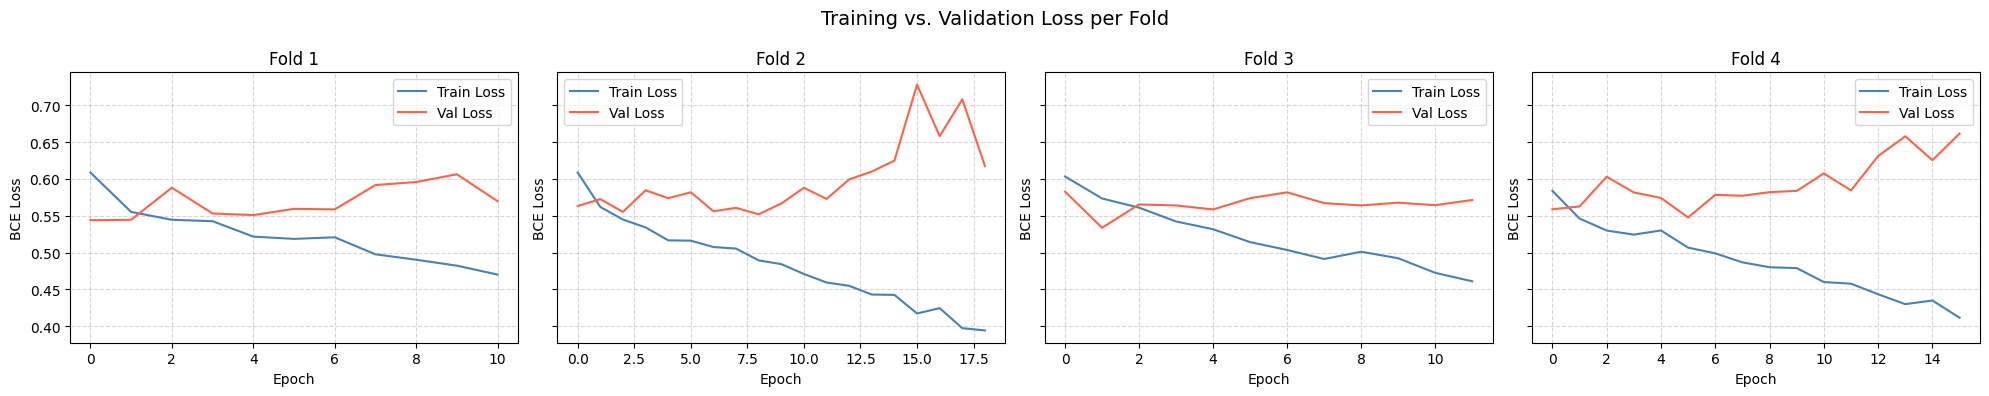

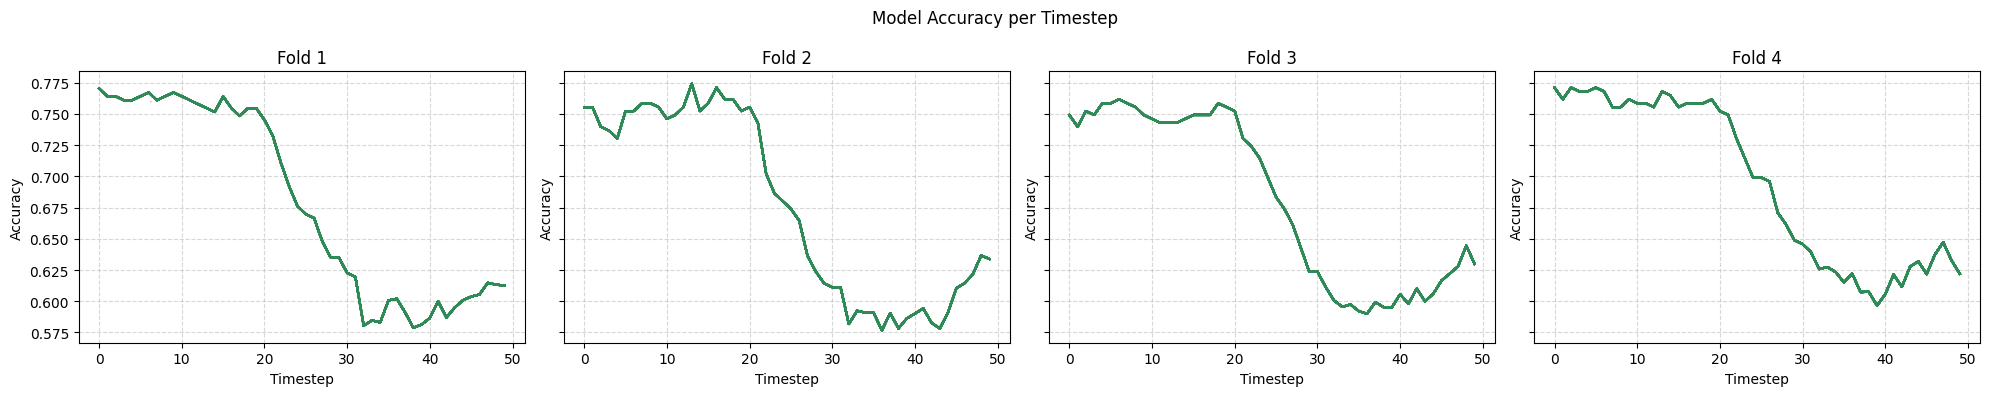


Minimal features needed at Hour 2 (Timestep 4):
 - severity (Score: 0.0713)
 - c-reactive_protein (Score: 0.0711)
 - respiratory_rate (Score: 0.0683)
 - hemoglobin (Score: 0.0597)
 - procalcitonin (Score: 0.0573)
 - pancreatic_lipase (Score: 0.0540)
 - leukocytes (Score: 0.0518)
 - partial_co2 (Score: 0.0502)
 - thrombocytes (Score: 0.0474)
 - lactate (Score: 0.0443)
 - bicarbonate (Score: 0.0419)
 - heart_time_volume (Score: 0.0400)
 - quick_score (Score: 0.0400)
 - lymphocytes (Score: 0.0399)
 - chloride (Score: 0.0372)
 - aspartate_transaminase (Score: 0.0369)


In [25]:
final_folds = prepare_data_and_create_folds(capped_dfs, sequence_length=50, n_features=44, hours_shift=6)

overall_metrics, interval_accuracies, interval_importances, final_weights, fold_metrics, best_fold_idx = run_cross_validation(
    folds=final_folds, 
    epochs=100, 
    batch_size=32, 
    learning_rate=0.01, 
    hidden_size=64,
    patience=10
)

# use the real feature column names instead of generic placeholders
feature_names = list(dfs[0].columns.drop(["id", "timestep", "sepsis"]))

# print minimal features for specific interval 
minimal_features = extract_minimal_features_per_interval(interval_importances, feature_names)

print("\nMinimal features needed at Hour 2 (Timestep 4):")
for item in minimal_features["Timestep_4"]:
    print(f" - {item['feature']} (Score: {item['importance']:.4f})")


In [26]:
# save the model
os.makedirs('models', exist_ok=True)

model_filepath = 'models/best_rnn_6hrs_shift.npy'

np.save(model_filepath, final_weights)

print(f"Model successfully saved to: {model_filepath}")

Model successfully saved to: models/best_rnn_6hrs_shift.npy


## Task 3: Outline training strategy and motivate it

During training, I used the proposed architecture and started with 20 epochs. At 20 epochs, I noticed that the avg precision is at 24%, an increase in the epoch size to 70 increased this to around 30% for all folds respectively with the average accuracy staying between 68 and 70%. Setting the epochs to 100 leads to only minimal increases in the model performance with an average precision of up to 38% and average accuracy of 60 to 70%. As the accuracy decreases, I leave the epochs at 100 for the best balanced model. In the final version, I also decreased the number of neurons for the hidden layer to 64 which furthermore increased model performance. I furthermore used four folds for the training as described earlier. 

The outputs are similar across all three prediction timespans (2, 4 and 6 hours) with the values only changing minimally and the general message of the outputs staying the same. 

## Task 4: Motivate which error scores you used and why

I utilized Binary Cross-Entropy (BCE) as the loss function, as it is the standard for binary classification tasks where the goal is to predict a probability between 0 and 1. To maintain mathematical integrity, I implemented a masking array within the BCE calculation. This ensured that the padded timesteps, which I added to equalize patient sequence lengths, did not contribute to the gradient updates, preventing the model from learning from artifacts of the data preparation process.

Given the significant class imbalance typical of sepsis datasets, Accuracy was deemed an insufficient metric. I prioritized Recall and F1-Score to evaluate the model's clinical utility. My cross-validation results showed an average Recall of 28.5%, peaking at 47.5% in Fold 1. While a Recall of ~28% indicates that the model is conservative—prioritizing the avoidance of false alarms (Precision)—the peaking performance suggests that with further hyperparameter tuning or more advanced architectures (like LSTMs), the RNN can effectively capture the temporal signatures of sepsis onset.

## Task 5: Describe feature importance carefully 

Top 10 Features by Permutation Importance (F1-Score Drop):
   1. respiratory_rate               +0.0463
   2. procalcitonin                  +0.0442
   3. fraction_of_inspired_o2        +0.0349
   4. c-reactive_protein             +0.0257
   5. lactate                        +0.0248
   6. heart_time_volume              +0.0247
   7. diastolic_bp                   +0.0184
   8. blood_urea_nitrogen            +0.0164
   9. bun/creatinine_ratio           +0.0157
  10. calcium                        +0.0149


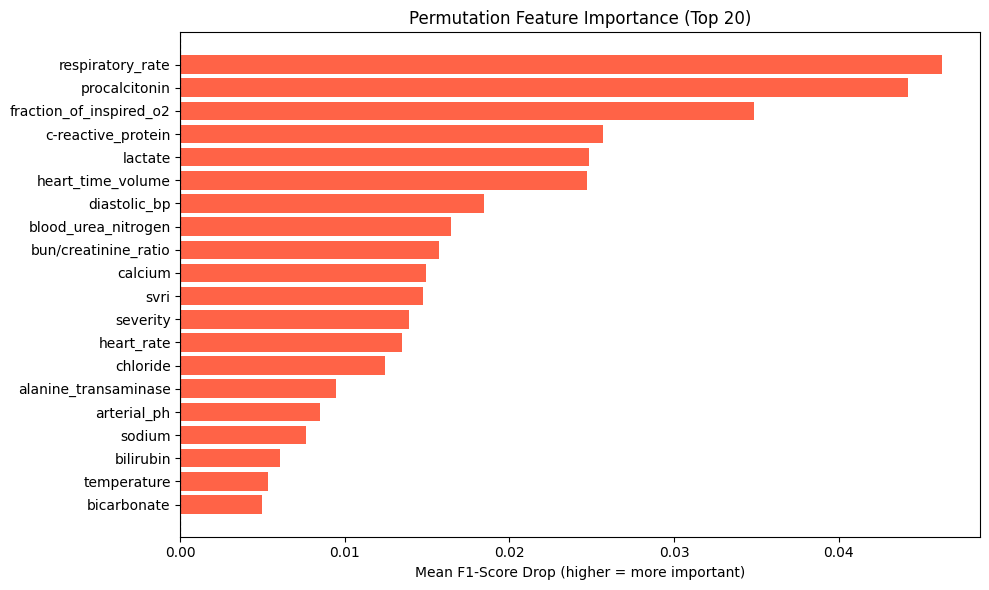

In [27]:
# calculate and plot permutation importance
perm_importance = permutation_importance(final_folds, final_weights, feature_names, n_repeats=5)

print("Top 10 Features by Permutation Importance (F1-Score Drop):")
sorted_perm = sorted(perm_importance.items(), key=lambda x: x[1], reverse=True)
for rank, (feat, score) in enumerate(sorted_perm[:10], 1):
    print(f"  {rank:2d}. {feat:<30s} {score:+.4f}")

plot_permutation_importance(perm_importance, top_n=20)


Top 10 Features by Gradient Saliency (mean |dL/dx|):
   1. severity                       0.0832
   2. c-reactive_protein             0.0820
   3. respiratory_rate               0.0713
   4. hemoglobin                     0.0629
   5. pancreatic_lipase              0.0568
   6. procalcitonin                  0.0556
   7. thrombocytes                   0.0524
   8. leukocytes                     0.0495
   9. partial_co2                    0.0487
  10. bicarbonate                    0.0452

Comparing both methods (normalised scores):


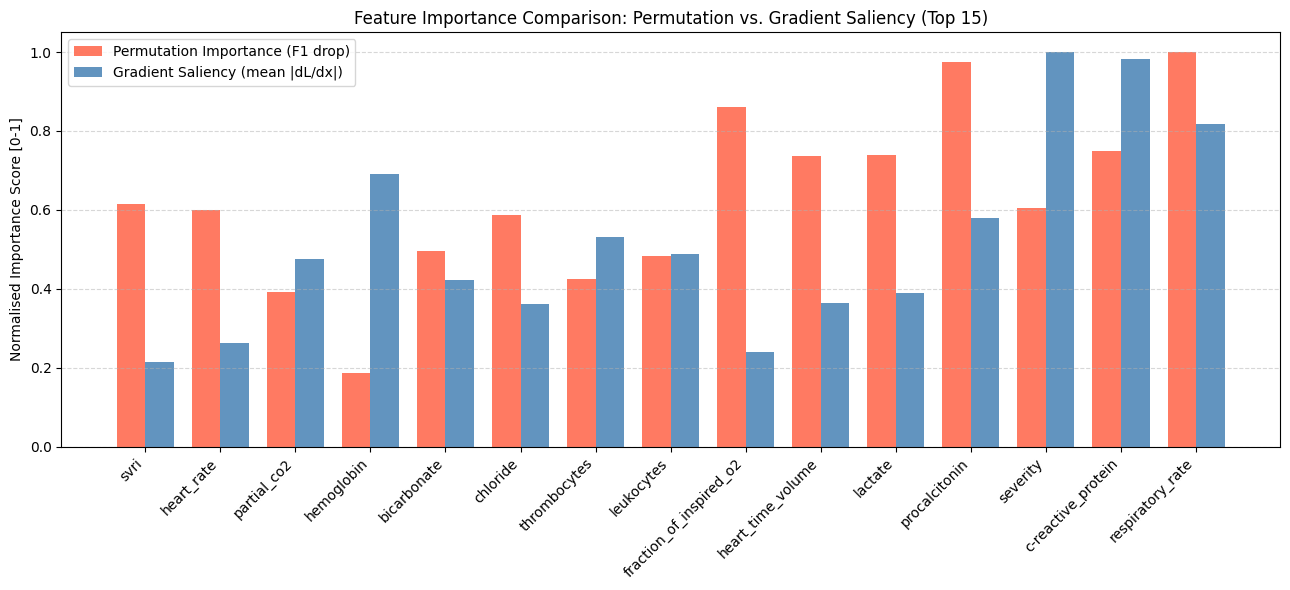


Features in Top 10 of BOTH methods (3):
  - c-reactive_protein  |  Perm: +0.0257  |  Grad: 0.0820
  - procalcitonin  |  Perm: +0.0442  |  Grad: 0.0556
  - respiratory_rate  |  Perm: +0.0463  |  Grad: 0.0713


In [28]:
# --- Gradient Saliency Importance ---
grad_importance = gradient_saliency_importance(interval_importances, feature_names)

print("Top 10 Features by Gradient Saliency (mean |dL/dx|):")
sorted_grad = sorted(grad_importance.items(), key=lambda x: x[1], reverse=True)
for rank, (feat, score) in enumerate(sorted_grad[:10], 1):
    print(f"  {rank:2d}. {feat:<30s} {score:.4f}")

# --- Direct Comparison Plot ---
print("\nComparing both methods (normalised scores):")
plot_importance_comparison(perm_importance, grad_importance, feature_names, top_n=15)

# --- Overlap: features that appear in the top 10 of BOTH methods ---
top10_perm = {f for f, _ in sorted_perm[:10]}
top10_grad = {f for f, _ in sorted_grad[:10]}
overlap = top10_perm & top10_grad
print(f"\nFeatures in Top 10 of BOTH methods ({len(overlap)}):")
for f in sorted(overlap):
    print(f"  - {f}  |  Perm: {perm_importance[f]:+.4f}  |  Grad: {grad_importance[f]:.4f}")


To determine feature importance, I applied two complementary methods and compared their results directly.

Permutation Importance measures the global influence of each feature by randomly shuffling its values across all patients and timesteps and recording the mean drop in F1-Score across all folds. A higher drop indicates a more important feature. The top 20 features are visualised in the bar chart above. The first three features — respiratory rate, procalcitonin, and fraction of inspired oxygen (FiO₂) — stand out as substantially more important than the rest, covering respiratory and biochemical dimensions of the sepsis response.

Gradient Saliency is a model-intrinsic method that measures how sensitive the loss is to small changes in each input feature at every timestep. The global score is obtained by averaging the absolute gradients over all active (non-padded) timesteps across all folds. This method highlighted severity as the single highest-scoring feature, while respiratory and biochemical markers also ranked highly — consistent with the permutation results.

Cross-method comparison: The side-by-side normalised plot shows that both methods agree on a small set of high-impact clinical markers. Features appearing in the Top 10 of both methods (see overlap printout above) represent the most robustly identified predictors, as their importance is confirmed by two independent analysis approaches. The agreement between a model-agnostic method (permutation) and a model-intrinsic method (gradient saliency) strengthens confidence in these features as genuine physiological predictors of sepsis onset rather than artefacts of the model architecture.

The above evaluation is based on the results of the hour shift with a value of 6 (hours). Comparing the model results across all three hour shifts (2, 4 and 6), the respiratory rate is equally important with it's position staying in the top three. The other features stay at the top positions as well but change order and move out of the top three for some cases and stay for others. The importance of severety in the gradient saliency method is rather high across all three variations but only reaches a value of close to 1 at the variation with a time shift of 6 hours. Top features for hour shifts 4 and 6 are similar with c-reactive protein and respiratory rate being ranked highest among severity for the gradient sliency method. Similar values are visible for the permutation importance method with procalcitonin, respiratory rate and c-reactive protein being in the top three. These evaluations show that feature importance does not change with the change of the predicition parameter. 

## Results and Discussion 

### Results

**Summary of Best Model Performance**

In [29]:
from IPython.display import display

# Evaluate final_weights on every fold's test set to find the best fold
best_fold_metrics = fold_metrics[best_fold_idx]

metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
df_summary = pd.DataFrame({
    "Metric": metric_labels,
    "CV Average": [f"{v * 100:.2f}%" for v in overall_metrics],
    f"Peak Performance (Fold {best_fold_idx + 1})": [f"{v * 100:.2f}%" for v in best_fold_metrics],
}).set_index("Metric")

display(df_summary)

,CV Average,Peak Performance (Fold 4)
Metric,,
Accuracy,72.92%,74.15%
Precision,41.44%,48.84%
Recall,12.95%,14.24%
F1-Score,19.66%,22.05%


---

### Key Discussion Points (evaluation based on an hour shift with value 6 (hours))

Model Tuning and Training Strategy:
The model was explicitly tuned for early detection by shifting target labels by two, four or six hours, forcing the network to identify predictive physiological patterns preceding clinical sepsis. Because real-time prediction is often too late for intervention, this training strategy prioritized predictive future-state recall over immediate concurrent accuracy.

Error Scores and Evaluation:
Binary Cross-Entropy (BCE) with a masking array was utilized as the loss function to penalize incorrect predictions while mathematically ignoring padded timesteps. Due to the severe class imbalance typical of medical datasets, accuracy is a highly misleading metric. Therefore, the evaluation prioritized Recall to minimize critical false negatives (missed sepsis cases) and the F1-Score to balance precision and prevent hospital alarm fatigue. The output of the evaluation metrics shows that the peak performance of the model at fold 2 (for 6 hours prediction) is still not production ready as the low recall and f1-scores of 14.70% and 21.36% show. The values for the 4 and 2 hours prediction windows become slightly better across all four metrics, suggesting that an increase in the prediciton window value cloud negatively influence model performance.

Architectural Effects:
The Recurrent Neural Network (RNN) architecture enabled the temporal tracking of a patient's gradual physiological decline via its hidden state memory. However, the RNN is fundamentally constrained by the vanishing gradient problem. As the patient sequence length increases to 50 timesteps (=25 hours), the network struggles to retain early timestep information, naturally tuning the model to rely more heavily on recent physiological changes rather than deep historical data.

Feature Importance and Minimal Set:
Two complementary methods were used to identify the most predictive features. Permutation Importance (model-agnostic) ranked respiratory rate, procalcitonin, and fraction of inspired oxygen (FiO₂) as the top three features by F1-Score drop. Gradient Saliency additionally highlighted severity as the feature with the highest mean sensitivity across all active timesteps. Features confirmed by both methods represent the most robustly identified predictors. The overlap between the two methods confirms that the RNN successfully synthesised biochemical (procalcitonin), respiratory (respiratory rate, FiO₂), and clinical severity signals into a coherent early warning profile.

## Citations

#### Shell script to create the train/dev/test split
@inproceedings{schamoni2022,
  author = {Schamoni, Shigehiko and Hagmann, Michael and Riezler, Stefan},
  title = {Ensembling Neural Networks for Improved Prediction and Privacy in Early Diagnosis of Sepsis},
  booktitle = {Proceedings of the 6th Machine Learning for Healthcare Conference},
  year = {2022},
  city = {Durham, NC},
  country = {USA},
  volume = {182},
  series = {Proceedings of Machine Learning Research},
  publisher = {PMLR},
  url = {https://www.cl.uni-heidelberg.de/~schamoni/publications/dl/MLHC2022_Ensembling.pdf}
}

I used this source as base for the theoretical knowledge to create the forward and backward propagation. 
https://www.kaggle.com/code/ravaghi/neural-networks-from-scratch-using-only-numpy 